# MIMIC Fidelity Analysis: Real-Data Validation of the Positive-Count Hypothesis

What this notebook does:

- Compares an interaction estimated from real ICU records against the same
  interaction estimated from a synthetic copy of those records.
- Holds the generator fixed at CART, `synthpop`'s default. The question is not
  which tree-based method does better, it is how one of them behaves when the
  stratum it has to reproduce is small.
- Varies the subsample two ways and reads the two coefficients against each other:
  - **Experiment 1, count sweep**: positive count varies, sample size fixed.
  - **Experiment 2, size sweep**: sample size varies, positive count fixed.
  - Neither separates the positive count from prevalence on its own. Together they
    do.

Where it sits:

- `synthetic-fidelity-analysis.ipynb` establishes the mechanism on simulated data
  where the true interaction is known.
- This notebook asks whether that holds on real records, where the truth is
  unknown and the effects are much smaller.
- `tree-structure-diagnosis.ipynb` picks up from here and looks inside the
  generator to ask why the estimates behave the way they do.

# Data

MIMIC-IV v2.2, restricted to hospital admissions with an ICU stay. Queries live in
`code/sql/`. The end product is `pool`: one row per ICU stay with demographics,
five comorbidity flags and first-day creatinine.

## Setup

SQL lives in `code/sql/` and loads via `read_sql()`. Paths are relative to `code/`,
same as `source("config.R")`.

`EXPLODE_THRESHOLD` sits here because every summary downstream uses it. A logistic
fit that hits quasi-separation throws out a huge coefficient. The full-pool
estimates are around 0.05, so anything past 2 is a failed fit, not a big effect.

In [1]:
library(duckdb)
library(DBI)
library(dplyr)
library(synthpop)
library(ggplot2)
library(tidyr)

source("config.R")

EXPLODE_THRESHOLD <- 2

read_sql <- function(name) {
  paste(readLines(file.path("sql", paste0(name, ".sql"))), collapse = "\n")
}

Loading required package: DBI


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


New version of synthpop (1.9-0) with disclosure functions
see disclosure.pdf for details and NEWS file for other changes

Find out more at https://www.synthpop.org.uk/



In [2]:
con <- dbConnect(duckdb())

views <- c(
  diagnoses_icd   = "hosp/diagnoses_icd.csv.gz",
  d_icd_diagnoses = "hosp/d_icd_diagnoses.csv.gz",
  icustays        = "icu/icustays.csv.gz",
  patients        = "hosp/patients.csv.gz",
  admissions      = "hosp/admissions.csv.gz",
  labevents       = "hosp/labevents.csv.gz",
  d_labitems      = "hosp/d_labitems.csv.gz"
)

for (v in names(views)) {
  dbExecute(con, sprintf("CREATE VIEW %s AS SELECT * FROM read_csv_auto('%s/%s')",
                         v, DATA_DIR, views[[v]]))
}

duckdb keeps downloaded extensions and secrets in a temporary directory:
ℹ /var/folders/5d/pvxmh0mx4f124ss1c7t2ymk00000gn/T//RtmpiaeHrG/duckdb
This is removed when the R session ends.
• Extensions are re-downloaded each session.
• Secrets are lost.
ℹ Run duckdb(shared_home = TRUE) (or create ~/.duckdb) to keep them (suitable for most users).
ℹ Run duckdb(shared_home = FALSE) to accept the temporary directory (and silence this message).
ℹ See ?duckdb_storage for details and alternatives.


## Comorbidity Screening: Positive Count by Category

Five comorbidities defined by simplified ICD-9 and ICD-10 groupings, counted over
admissions with an ICU stay. The three least common are carried forward. Renal
failure is left out for a second reason: it overlaps mechanically with creatinine,
so an interaction between them would be close to tautological.

In [3]:
comorbidity_counts <- dbGetQuery(con, read_sql("comorbidity_counts"))
print(comorbidity_counts)

    comorbidity positive_count
1          COPD           7244
2           CHF          17412
3      Diabetes          19806
4 Renal Failure          25369
5  Hypertension          34979


## Continuous Variable Selection

Five first-day labs were available. Four of them cover almost everyone:

| lab | coverage |
|---|---|
| Glucose | 97.0% |
| Creatinine | 97.0% |
| Hemoglobin | 96.5% |
| WBC | 96.3% |
| Lactate | 53.2% |

Lactate was the first candidate, clinically tied to CHF through poor cardiac
output and matching the simulation notebook. It was dropped on the 53% coverage,
and the reason matters: lactate is ordered when shock is suspected rather than
routinely, so whether the value exists is itself tied to how sick the patient is.
That is informative missingness, not just thin data.

Creatinine replaces it. Comparable clinical link through cardiorenal syndrome, at
97% coverage.

The first-day maximum is taken, following the SOFA convention of using the worst
value in 24 hours, then capped at the 99.5th percentile (11 mg/dL) so a few
extreme values cannot dominate a 500-row subsample. That is what
`creatinine_max_capped` is.

In [4]:
lab_coverage <- dbGetQuery(con, read_sql("lab_coverage"))
print(lab_coverage)


         lab n_with n_stays coverage_pct
1    Glucose  71007   73181         97.0
2 Creatinine  70954   73181         97.0
3 Hemoglobin  70623   73181         96.5
4        WBC  70507   73181         96.3
5    Lactate  38912   73181         53.2


In [5]:
creatinine_items <- dbGetQuery(con, read_sql("creatinine_items"))
print(creatinine_items)

  itemid                   label fluid  category
1  50912              Creatinine Blood Chemistry
2  52546              Creatinine Blood Chemistry
3  52024 Creatinine, Whole Blood Blood Blood Gas


In [6]:
creatinine_coverage <- dbGetQuery(con, read_sql("creatinine_coverage"))
print(creatinine_coverage)

  n_stays n_with_creatinine coverage_pct
1   73181             70954           97


In [7]:
creatinine_firstday <- dbGetQuery(con, read_sql("creatinine_firstday"))
str(creatinine_firstday)
summary(creatinine_firstday$creatinine_max)

'data.frame':	70954 obs. of  2 variables:
 $ stay_id       : num  38659868 34170660 35068745 34970562 30838896 ...
 $ creatinine_max: num  1.8 0.7 0.6 1.7 0.8 1.6 0.9 2.3 0.9 0.7 ...


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.700   1.000   1.509   1.500  80.000 

In [8]:
CAP <- quantile(creatinine_firstday$creatinine_max, 0.995, na.rm = TRUE)
creatinine_firstday$creatinine_max_capped <- pmin(creatinine_firstday$creatinine_max, CAP)
print(CAP)

99.5% 
   11 


## Build Flat Table

One row per ICU stay, joining demographics, admission details and the comorbidity
flags. `ORDER BY stay_id` is there so repeated runs return rows in the same order,
which the subsampling depends on.

In [9]:
cohort_base <- dbGetQuery(con, read_sql("cohort_base"))
str(cohort_base)

'data.frame':	73181 obs. of  16 variables:
 $ stay_id             : num  3e+07 3e+07 3e+07 3e+07 3e+07 ...
 $ hadm_id             : num  23998182 27543152 22413411 22795209 23552849 ...
 $ subject_id          : num  12466550 13180007 18421337 12207593 12980335 ...
 $ intime              : POSIXct, format: "2174-09-29 12:09:00" "2162-06-21 05:38:00" ...
 $ outtime             : POSIXct, format: "2174-10-01 03:26:10" "2162-06-22 20:52:48" ...
 $ los                 : num  1.64 1.64 2.48 4.7 1.14 ...
 $ gender              : chr  "M" "M" "M" "M" ...
 $ anchor_age          : num  61 64 91 43 68 77 40 56 86 33 ...
 $ admission_type      : chr  "EW EMER." "EW EMER." "EW EMER." "EW EMER." ...
 $ insurance           : chr  "Other" "Medicare" "Medicare" "Medicaid" ...
 $ hospital_expire_flag: num  0 0 0 1 0 0 0 0 0 0 ...
 $ chf                 : int  0 1 1 0 0 1 0 0 0 0 ...
 $ diabetes            : int  0 1 0 0 0 1 0 0 0 0 ...
 $ copd                : int  0 0 0 0 1 0 0 0 1 0 ...
 $ renal_failu

## Preprocessing and Analysis Pool

Identifiers and timestamps are dropped and binaries become factors, so `synthpop`
treats them as categorical rather than numeric.

`flat_table` holds all 73,181 stays. `pool` is the same table minus the 3% with no
first-day creatinine, leaving 70,954 rows, and is what everything downstream
samples from.

In [10]:
preprocess <- function(df) {
  df$stay_id    <- NULL
  df$hadm_id    <- NULL
  df$subject_id <- NULL
  df$intime     <- NULL
  df$outtime    <- NULL

  df$gender               <- factor(df$gender)
  df$admission_type       <- factor(df$admission_type)
  df$insurance             <- factor(df$insurance)
  df$hospital_expire_flag <- factor(df$hospital_expire_flag, levels = c(0, 1))
  df$chf                  <- factor(df$chf,           levels = c(0, 1))
  df$diabetes             <- factor(df$diabetes,      levels = c(0, 1))
  df$copd                 <- factor(df$copd,          levels = c(0, 1))
  df$renal_failure        <- factor(df$renal_failure, levels = c(0, 1))
  df$hypertension         <- factor(df$hypertension,  levels = c(0, 1))

  return(df)
}

flat_table <- cohort_base %>%
  left_join(
    creatinine_firstday %>% select(stay_id, creatinine_max_capped),
    by = "stay_id"
  )

flat_table <- preprocess(flat_table)

pool <- flat_table %>% filter(!is.na(creatinine_max_capped))

str(pool)


'data.frame':	70954 obs. of  12 variables:
 $ los                  : num  1.64 1.64 2.48 4.7 1.14 ...
 $ gender               : Factor w/ 2 levels "F","M": 2 2 2 2 2 2 2 2 1 2 ...
 $ anchor_age           : num  61 64 91 43 68 77 40 56 68 43 ...
 $ admission_type       : Factor w/ 9 levels "AMBULATORY OBSERVATION",..: 6 6 6 6 9 9 6 6 6 8 ...
 $ insurance            : Factor w/ 3 levels "Medicaid","Medicare",..: 3 2 2 1 3 3 2 3 2 3 ...
 $ hospital_expire_flag : Factor w/ 2 levels "0","1": 1 1 1 2 1 1 1 1 1 1 ...
 $ chf                  : Factor w/ 2 levels "0","1": 1 2 2 1 1 2 1 1 1 1 ...
 $ diabetes             : Factor w/ 2 levels "0","1": 1 2 1 1 1 2 1 1 1 2 ...
 $ copd                 : Factor w/ 2 levels "0","1": 1 1 1 1 2 1 1 1 1 1 ...
 $ renal_failure        : Factor w/ 2 levels "0","1": 1 2 2 1 1 2 2 2 1 1 ...
 $ hypertension         : Factor w/ 2 levels "0","1": 1 2 1 1 2 2 1 1 1 2 ...
 $ creatinine_max_capped: num  1.1 3.7 1.2 1 0.6 1.1 1.6 2.7 0.5 0.9 ...


# Estimation Functions

One trial draws a stratified subsample, synthesises it with `synthpop`, and fits
the same logistic model to both tables. The rest is bookkeeping: the sweeps loop
trials over a grid, and `summarise_sweep()` collapses replicates into failure
rates and quantiles.

## get_interaction()

In [11]:
get_interaction <- function(df, comorbidity_col) {
  formula_str <- paste0("hospital_expire_flag ~ anchor_age + creatinine_max_capped + ",
                         comorbidity_col, " + ", comorbidity_col, ":creatinine_max_capped")
  fit <- suppressWarnings(glm(as.formula(formula_str), data = df, family = binomial))
  coef(fit)[paste0("creatinine_max_capped:", comorbidity_col)]
}

## run_one_trial()

In [12]:
run_one_trial <- function(k, seed, n_fixed, pos_pool, neg_pool, comorbidity_col) {
  set.seed(seed)

  sub <- bind_rows(
    pos_pool[sample(nrow(pos_pool), k), ],
    neg_pool[sample(nrow(neg_pool), n_fixed - k), ]
  )

  syn_obj <- syn(sub, seed = seed, print.flag = FALSE)
  syn     <- syn_obj$syn

  sub[[comorbidity_col]] <- as.numeric(as.character(sub[[comorbidity_col]]))
  syn[[comorbidity_col]] <- as.numeric(as.character(syn[[comorbidity_col]]))

  real_est <- get_interaction(sub, comorbidity_col)
  syn_est  <- get_interaction(syn, comorbidity_col)

  data.frame(
    count         = k,
    rep           = seed,
    real_est      = real_est,
    syn_est       = syn_est,
    real_exploded = abs(real_est) > EXPLODE_THRESHOLD,
    syn_exploded  = abs(syn_est)  > EXPLODE_THRESHOLD
  )
}

## summarise_sweep()

Each row covers `M` replicates at one grid point. `M` is set in the parameters
cell above, so there is no per-row count column.

Quantiles use only the replicates that converged; the non-convergence rate sits
beside them in its own column. They answer different questions, so keeping them
apart matters: how variable a successful estimate is, versus how often estimation
fails at all.

A replicate is flagged when its interaction estimate goes past
`EXPLODE_THRESHOLD`, which marks quasi-separation rather than a large effect. The
two arms are filtered separately, so a replicate whose real fit converged but
whose synthetic fit did not still counts toward the real quantiles.


In [13]:
summarise_sweep <- function(results, by) {
  results %>%
    group_by(across(all_of(by))) %>%
    summarise(
      # both failure modes are shares of all M replicates, so
      # converged = 1 - na - expl
      pct_real_na   = mean(is.na(real_est)),
      pct_syn_na    = mean(is.na(syn_est)),
      pct_real_expl = mean(!is.na(real_est) & abs(real_est) > EXPLODE_THRESHOLD),
      pct_syn_expl  = mean(!is.na(syn_est)  & abs(syn_est)  > EXPLODE_THRESHOLD),
      # names above differ from real_exploded / syn_exploded on purpose:
      # summarise() evaluates in order, so reusing a source column's name
      # would shadow it for every expression that follows
      real_q25 = quantile(real_est[!real_exploded], 0.25, na.rm = TRUE),
      real_q50 = quantile(real_est[!real_exploded], 0.50, na.rm = TRUE),
      real_q75 = quantile(real_est[!real_exploded], 0.75, na.rm = TRUE),
      syn_q25  = quantile(syn_est[!syn_exploded],  0.25, na.rm = TRUE),
      syn_q50  = quantile(syn_est[!syn_exploded],  0.50, na.rm = TRUE),
      syn_q75  = quantile(syn_est[!syn_exploded],  0.75, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    mutate(real_width = real_q75 - real_q25,
           syn_width  = syn_q75  - syn_q25)
}

## run_comorbidity_sweep()

In [14]:
run_comorbidity_sweep <- function(comorbidity_col, pool, counts, n_fixed, M) {
  pos_pool <- pool %>% filter(.data[[comorbidity_col]] == "1")
  neg_pool <- pool %>% filter(.data[[comorbidity_col]] == "0")

  results <- lapply(counts, function(k) {
    lapply(seq_len(M), function(r) {
      run_one_trial(k, seed = k * 1000 + r, n_fixed, pos_pool, neg_pool, comorbidity_col)
    }) %>% bind_rows()
  }) %>% bind_rows()

  results$comorbidity <- comorbidity_col

  list(results = results, quantile_summary = summarise_sweep(results, "count"))
}

## run_size_sweep()

Mirrors `run_comorbidity_sweep()` with the two levers swapped: the positive count
is held fixed and the total sample size is varied instead. Because k never moves,
prevalence (k / n) is the only quantity changing, which is what separates a count
effect from a prevalence effect. The count sweep cannot do this, since fixing n
welds those two together.

`run_one_trial()` already accepts `n_fixed` as an argument, so it is reused
unchanged; only the loop structure differs.

In [15]:
run_size_sweep <- function(comorbidity_col, pool, k_fixed, sizes, M) {
  pos_pool <- pool %>% filter(.data[[comorbidity_col]] == "1")
  neg_pool <- pool %>% filter(.data[[comorbidity_col]] == "0")

  results <- lapply(sizes, function(n) {
    lapply(seq_len(M), function(r) {
      run_one_trial(k_fixed, seed = n * 100 + k_fixed * 1000 + r,
                    n_fixed = n, pos_pool, neg_pool, comorbidity_col) %>%
        mutate(n_fixed = n)
    }) %>% bind_rows()
  }) %>% bind_rows()

  results$comorbidity <- comorbidity_col

  quantile_summary <- summarise_sweep(results, "n_fixed") %>%
    mutate(prevalence = k_fixed / n_fixed, .after = n_fixed)

  list(results = results, quantile_summary = quantile_summary)
}

## full_interaction_test()

Supersedes an earlier `get_full_est()` that returned only the coefficient.
The standard error and p-value are what let the interaction be placed
against the main effect it modulates.

In [ ]:
full_interaction_test <- function(comorbidity_col, pool) {
  pool_num <- pool
  pool_num[[comorbidity_col]] <- as.numeric(as.character(pool_num[[comorbidity_col]]))

  f <- as.formula(paste0("hospital_expire_flag ~ anchor_age + creatinine_max_capped + ",
                         comorbidity_col, " + ", comorbidity_col, ":creatinine_max_capped"))
  fit <- suppressWarnings(glm(f, data = pool_num, family = binomial))

  cf   <- coef(summary(fit))
  term <- grep(paste0("^(creatinine_max_capped:", comorbidity_col, "|",
                      comorbidity_col, ":creatinine_max_capped)$"),
               rownames(cf), value = TRUE)

  data.frame(
    comorbidity = comorbidity_col,
    estimate    = cf[term, "Estimate"],
    std_error   = cf[term, "Std. Error"],
    z           = cf[term, "z value"],
    p           = cf[term, "Pr(>|z|)"],
    row.names   = NULL
  )
}

# The Full-Pool Reference

MIMIC-IV has no known ground truth, so the interaction fit on the whole
pool stands in as the reference the sweeps are read against. The three
`FULL_EST_*` values are the dashed lines in the ribbon plots below.

In [ ]:
full_ref <- bind_rows(lapply(c("chf", "diabetes", "copd"),
                             full_interaction_test, pool = pool))
print(full_ref)

FULL_EST_chf      <- full_ref$estimate[full_ref$comorbidity == "chf"]
FULL_EST_diabetes <- full_ref$estimate[full_ref$comorbidity == "diabetes"]
FULL_EST_copd     <- full_ref$estimate[full_ref$comorbidity == "copd"]

## full_model_coefs()

The same three models with every term retained, which is where the
creatinine and comorbidity main effects come from.

In [ ]:
full_model_coefs <- function(comorbidity_col, pool) {
  pool_num <- pool
  pool_num[[comorbidity_col]] <- as.numeric(as.character(pool_num[[comorbidity_col]]))

  f <- as.formula(paste0("hospital_expire_flag ~ anchor_age + creatinine_max_capped + ",
                         comorbidity_col, " + ", comorbidity_col, ":creatinine_max_capped"))
  fit <- suppressWarnings(glm(f, data = pool_num, family = binomial))

  cf <- coef(summary(fit))
  data.frame(comorbidity = comorbidity_col,
             term      = rownames(cf),
             estimate  = cf[, "Estimate"],
             std_error = cf[, "Std. Error"],
             p         = cf[, "Pr(>|z|)"],
             row.names = NULL)
}

do.call(rbind, lapply(c("chf", "diabetes", "copd"), full_model_coefs, pool = pool))

# Experiment 1: Count Sweep

Sample size is fixed at n = 500 and the positive count is varied. With n fixed,
prevalence moves in lockstep with the count, so this design cannot tell the two
apart. Experiment 2 does.

## Sweep Parameters

Shared by all three comorbidities so the grids stay comparable.

In [17]:
counts  <- c(5, 10, 20, 40, 80, 150, 250)
n_fixed <- 500
M       <- 100

## CHF × Creatinine

The full-pool estimate printed below is the reference line in the plot. The
clinical rationale is cardiorenal syndrome: raised creatinine is more expected in
CHF patients, so it should carry less additional mortality signal there.

In [19]:
sweep_chf <- run_comorbidity_sweep("chf", pool, counts, n_fixed, M)
print(sweep_chf$quantile_summary, width = Inf)

# A tibble: 7 × 13
  count pct_real_na pct_syn_na pct_real_expl pct_syn_expl real_q25 real_q50
  <dbl>       <dbl>      <dbl>         <dbl>        <dbl>    <dbl>    <dbl>
1     5           0       0.04          0.27         0.4    -0.409  -0.164 
2    10           0       0             0.18         0.21   -0.333  -0.172 
3    20           0       0             0.06         0.13   -0.314  -0.111 
4    40           0       0             0            0.02   -0.183  -0.0266
5    80           0       0             0            0      -0.159  -0.0457
6   150           0       0             0            0      -0.198  -0.0740
7   250           0       0             0            0      -0.162  -0.0709
  real_q75 syn_q25 syn_q50 syn_q75 real_width syn_width
     <dbl>   <dbl>   <dbl>   <dbl>      <dbl>     <dbl>
1  0.178    -0.433 -0.131   0.0414      0.588     0.474
2  0.00107  -0.285 -0.140   0.0165      0.334     0.301
3  0.130    -0.498 -0.108   0.127       0.444     0.625
4  0.124    -0.40

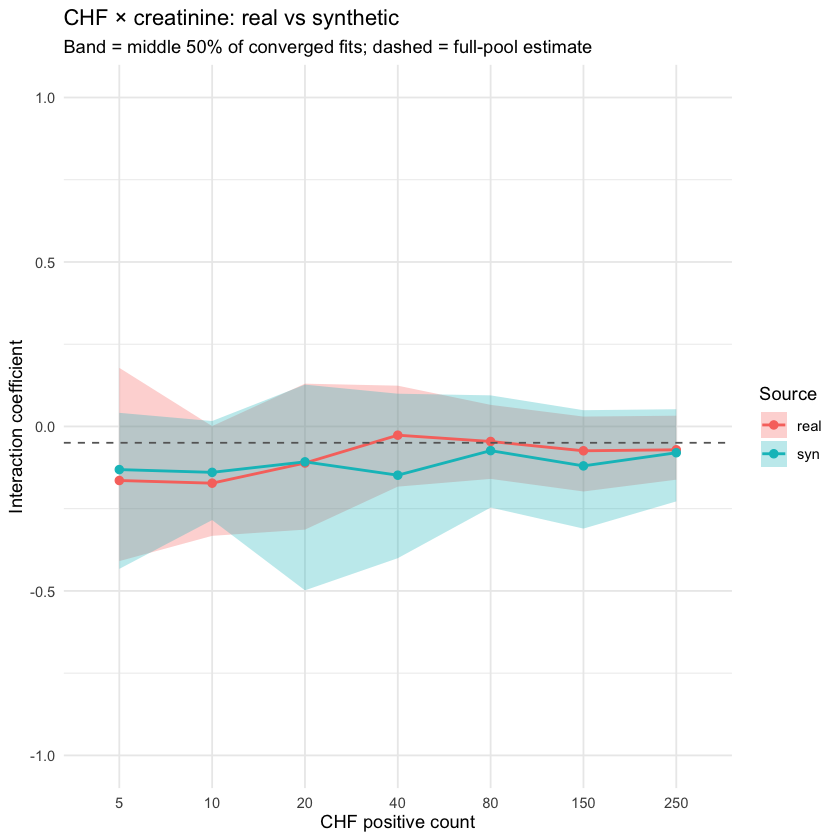

In [ ]:
plot_df <- sweep_chf$quantile_summary %>%
  pivot_longer(
    cols = matches("^(real|syn)_q[0-9]+$"),   # skip pct_*/width columns
    names_to = c("source", "quantile"),
    names_pattern = "(real|syn)_q(\\d+)",
    values_to = "value"
  ) %>%
  mutate(quantile = paste0("q", quantile)) %>%
  pivot_wider(names_from = quantile, values_from = value)

p_chf_ribbon <- ggplot(plot_df, aes(x = factor(count), color = source, fill = source)) +
  geom_ribbon(aes(ymin = q25, ymax = q75, group = source), alpha = 0.3, color = NA) +
  geom_line(aes(y = q50, group = source), linewidth = 0.8) +
  geom_point(aes(y = q50), size = 2) +
  geom_hline(yintercept = FULL_EST_chf, linetype = "dashed", color = "grey40") +
  coord_cartesian(ylim = c(-1, 1)) +
  labs(title = "CHF × creatinine: real vs synthetic",
       subtitle = "Band = middle 50% of converged fits; dashed = full-pool estimate",
       x = "CHF positive count", y = "Interaction coefficient",
       color = "Source", fill = "Source") +
  theme_minimal()


## Diabetes × Creatinine

Diabetic nephropathy gives the same creatinine link through a different mechanism.

In [22]:
sweep_diabetes <- run_comorbidity_sweep("diabetes", pool, counts, n_fixed, M)
print(sweep_diabetes$quantile_summary, width = Inf)

# A tibble: 7 × 13
  count pct_real_na pct_syn_na pct_real_expl pct_syn_expl real_q25 real_q50
  <dbl>       <dbl>      <dbl>         <dbl>        <dbl>    <dbl>    <dbl>
1     5           0       0.06          0.18         0.3    -0.395  -0.221 
2    10           0       0             0.19         0.22   -0.366  -0.168 
3    20           0       0             0.07         0.17   -0.295  -0.146 
4    40           0       0             0.02         0.04   -0.270  -0.0647
5    80           0       0             0            0      -0.235  -0.0956
6   150           0       0             0            0      -0.186  -0.0500
7   250           0       0             0            0      -0.200  -0.103 
  real_q75 syn_q25 syn_q50 syn_q75 real_width syn_width
     <dbl>   <dbl>   <dbl>   <dbl>      <dbl>     <dbl>
1 -0.0707   -0.488 -0.261  0.0377       0.324     0.525
2  0.234    -0.547 -0.217  0.0206       0.600     0.567
3  0.206    -0.505 -0.175  0.224        0.502     0.729
4  0.109    -0.37

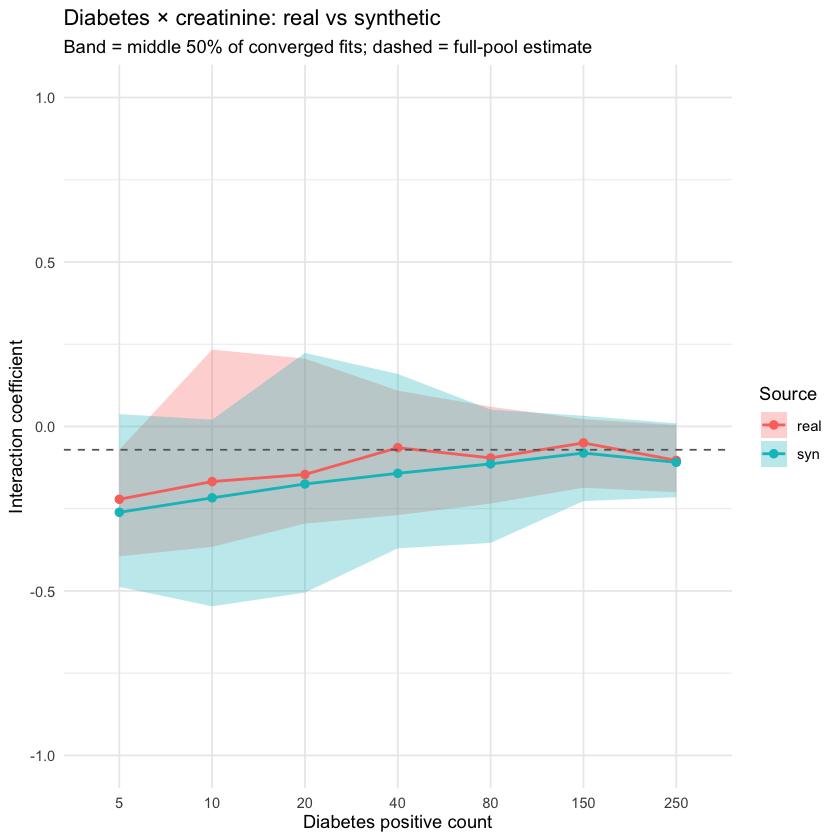

In [23]:
plot_df_dm <- sweep_diabetes$quantile_summary %>%
  pivot_longer(
    cols = matches("^(real|syn)_q[0-9]+$"),   # skip pct_*/width columns
    names_to = c("source", "quantile"),
    names_pattern = "(real|syn)_q(\\d+)",
    values_to = "value"
  ) %>%
  mutate(quantile = paste0("q", quantile)) %>%
  pivot_wider(names_from = quantile, values_from = value)

ggplot(plot_df_dm, aes(x = factor(count), color = source, fill = source)) +
  geom_ribbon(aes(ymin = q25, ymax = q75, group = source), alpha = 0.3, color = NA) +
  geom_line(aes(y = q50, group = source), linewidth = 0.8) +
  geom_point(aes(y = q50), size = 2) +
  geom_hline(yintercept = FULL_EST_diabetes, linetype = "dashed", color = "grey40") +
  coord_cartesian(ylim = c(-1, 1)) +
  labs(title = "Diabetes × creatinine: real vs synthetic",
       subtitle = "Band = middle 50% of converged fits; dashed = full-pool estimate",
       x = "Diabetes positive count", y = "Interaction coefficient",
       color = "Source", fill = "Source") +
  theme_minimal()

## COPD × Creatinine

COPD has the fewest positives of the three in the pool, so it is the hardest case
for the generator.

In [25]:
sweep_copd <- run_comorbidity_sweep("copd", pool, counts, n_fixed, M)
print(sweep_copd$quantile_summary, width = Inf)

# A tibble: 7 × 13
  count pct_real_na pct_syn_na pct_real_expl pct_syn_expl real_q25 real_q50
  <dbl>       <dbl>      <dbl>         <dbl>        <dbl>    <dbl>    <dbl>
1     5           0       0.05          0.34         0.23  -0.489   -0.230 
2    10           0       0             0.3          0.29  -0.352   -0.124 
3    20           0       0             0.13         0.15  -0.251    0.0308
4    40           0       0             0            0.03  -0.0904   0.109 
5    80           0       0             0            0      0.0201   0.129 
6   150           0       0             0            0     -0.0700   0.0517
7   250           0       0             0            0     -0.0498   0.0706
  real_q75 syn_q25  syn_q50 syn_q75 real_width syn_width
     <dbl>   <dbl>    <dbl>   <dbl>      <dbl>     <dbl>
1   -0.137 -0.407  -0.170    0.0171      0.351     0.424
2    0.309 -0.422  -0.168   -0.0104      0.661     0.411
3    0.469 -0.449  -0.177    0.172       0.720     0.621
4    0.319 -

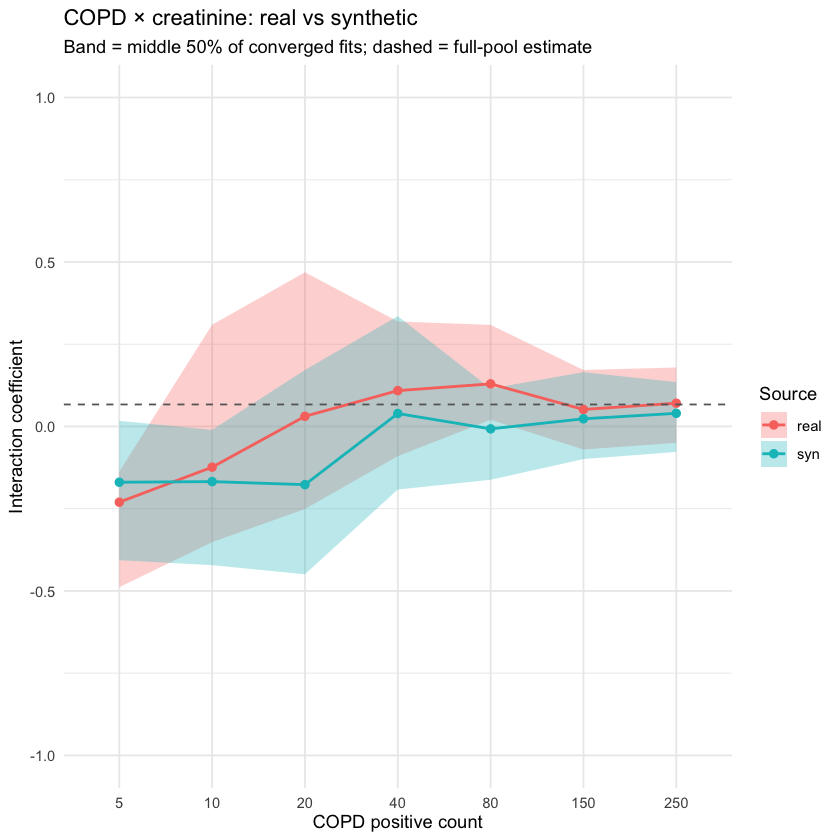

In [26]:
plot_df_copd <- sweep_copd$quantile_summary %>%
  pivot_longer(
    cols = matches("^(real|syn)_q[0-9]+$"),   # skip pct_*/width columns
    names_to = c("source", "quantile"),
    names_pattern = "(real|syn)_q(\\d+)",
    values_to = "value"
  ) %>%
  mutate(quantile = paste0("q", quantile)) %>%
  pivot_wider(names_from = quantile, values_from = value)

ggplot(plot_df_copd, aes(x = factor(count), color = source, fill = source)) +
  geom_ribbon(aes(ymin = q25, ymax = q75, group = source), alpha = 0.3, color = NA) +
  geom_line(aes(y = q50, group = source), linewidth = 0.8) +
  geom_point(aes(y = q50), size = 2) +
  geom_hline(yintercept = FULL_EST_copd, linetype = "dashed", color = "grey40") +
  coord_cartesian(ylim = c(-1, 1)) +
  labs(title = "COPD × creatinine: real vs synthetic",
       subtitle = "Band = middle 50% of converged fits; dashed = full-pool estimate",
       x = "COPD positive count", y = "Interaction coefficient",
       color = "Source", fill = "Source") +
  theme_minimal()

## Cross-Comorbidity Comparison

Failure rate and spread for all three comorbidities side by side. They answer
different questions and diverge at low counts, so neither summarises the sweep on
its own.

In [27]:
stability_compare <- bind_rows(
  sweep_chf$quantile_summary      %>% mutate(comorbidity = "CHF"),
  sweep_diabetes$quantile_summary %>% mutate(comorbidity = "Diabetes"),
  sweep_copd$quantile_summary     %>% mutate(comorbidity = "COPD")
) %>%
  select(comorbidity, count, pct_real_na, pct_syn_na,
         pct_real_expl, pct_syn_expl, real_width, syn_width)

In [28]:
print(stability_compare, width = Inf, n = Inf)

# A tibble: 21 × 8
   comorbidity count pct_real_na pct_syn_na pct_real_expl pct_syn_expl
   <chr>       <dbl>       <dbl>      <dbl>         <dbl>        <dbl>
 1 CHF             5           0       0.04          0.27         0.4 
 2 CHF            10           0       0             0.18         0.21
 3 CHF            20           0       0             0.06         0.13
 4 CHF            40           0       0             0            0.02
 5 CHF            80           0       0             0            0   
 6 CHF           150           0       0             0            0   
 7 CHF           250           0       0             0            0   
 8 Diabetes        5           0       0.06          0.18         0.3 
 9 Diabetes       10           0       0             0.19         0.22
10 Diabetes       20           0       0             0.07         0.17
11 Diabetes       40           0       0             0.02         0.04
12 Diabetes       80           0       0             0    

In [29]:
stability_compare %>% select(comorbidity, count, real_width, syn_width) %>% print(n = Inf)

# A tibble: 21 × 4
   comorbidity count real_width syn_width
   <chr>       <dbl>      <dbl>     <dbl>
 1 CHF             5      0.588     0.474
 2 CHF            10      0.334     0.301
 3 CHF            20      0.444     0.625
 4 CHF            40      0.307     0.500
 5 CHF            80      0.225     0.341
 6 CHF           150      0.228     0.360
 7 CHF           250      0.194     0.280
 8 Diabetes        5      0.324     0.525
 9 Diabetes       10      0.600     0.567
10 Diabetes       20      0.502     0.729
11 Diabetes       40      0.379     0.530
12 Diabetes       80      0.295     0.405
13 Diabetes      150      0.209     0.259
14 Diabetes      250      0.204     0.225
15 COPD            5      0.351     0.424
16 COPD           10      0.661     0.411
17 COPD           20      0.720     0.621
18 COPD           40      0.410     0.527
19 COPD           80      0.289     0.277
20 COPD          150      0.242     0.264
21 COPD          250      0.229     0.212


In [46]:
stability_long <- stability_compare %>%
  pivot_longer(cols = c(real_width, syn_width), names_to = "source", values_to = "width") %>%
  mutate(
    source      = ifelse(source == "real_width", "real", "syn"),
    comorbidity = factor(comorbidity, levels = c("CHF", "Diabetes", "COPD"))
  )
p_spread <- ggplot(stability_long, aes(x = factor(count), y = width, fill = source)) +
  geom_col(position = "dodge") +
  facet_wrap(~ comorbidity) +
  labs(title = "Estimate spread narrows as the positive count grows",
       subtitle = "Middle 50% of converged fits only",
       x = "Positive count", y = "Spread (middle 50%)",
       fill = "Source") +
  theme_minimal()


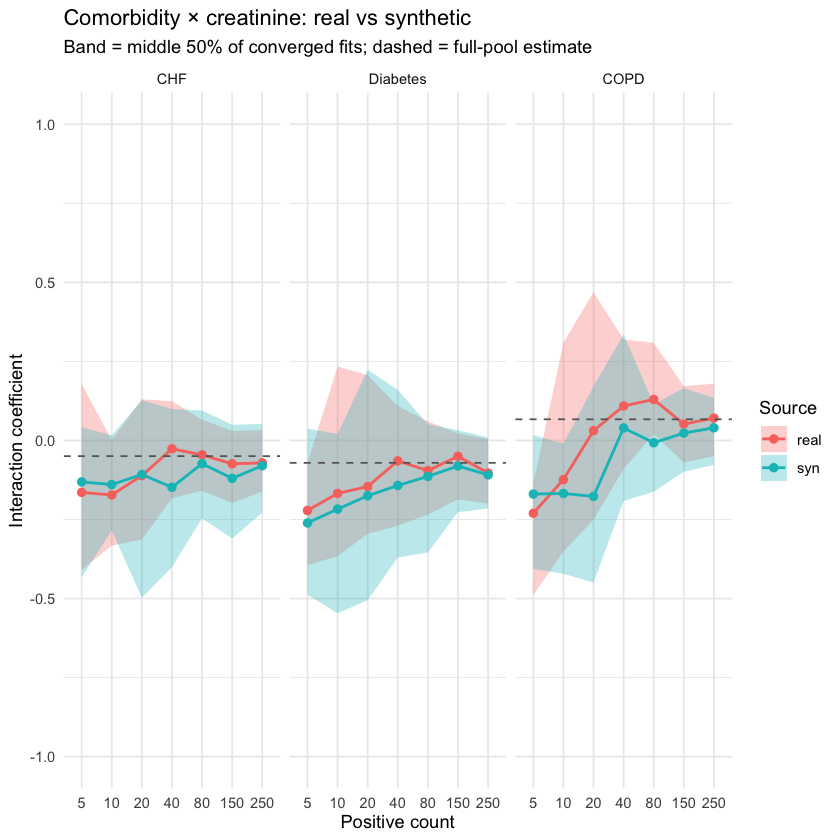

In [51]:
plot_df <- bind_rows(
    sweep_chf$quantile_summary      %>% mutate(comorbidity = "CHF"),
    sweep_diabetes$quantile_summary %>% mutate(comorbidity = "Diabetes"),
    sweep_copd$quantile_summary     %>% mutate(comorbidity = "COPD")
  ) %>%
  pivot_longer(
    cols = matches("^(real|syn)_q[0-9]+$"),   # skip pct_*/width columns
    names_to = c("source", "quantile"),
    names_pattern = "(real|syn)_q(\\d+)",
    values_to = "value"
  ) %>%
  mutate(quantile = paste0("q", quantile)) %>%
  pivot_wider(names_from = quantile, values_from = value) %>%
  mutate(comorbidity = factor(comorbidity, levels = c("CHF", "Diabetes", "COPD")))

ref_df <- tibble(
  comorbidity = factor(c("CHF", "Diabetes", "COPD"),
                       levels = c("CHF", "Diabetes", "COPD")),
  full_est    = c(FULL_EST_chf, FULL_EST_diabetes, FULL_EST_copd)
)

p_ribbon <- ggplot(plot_df, aes(x = factor(count), color = source, fill = source)) +
  geom_ribbon(aes(ymin = q25, ymax = q75, group = source), alpha = 0.3, color = NA) +
  geom_line(aes(y = q50, group = source), linewidth = 0.8) +
  geom_point(aes(y = q50), size = 2) +
  geom_hline(data = ref_df, aes(yintercept = full_est),
             linetype = "dashed", color = "grey40") +
  facet_wrap(~ comorbidity) +
  coord_cartesian(ylim = c(-1, 1)) +
  labs(title = "Comorbidity × creatinine: real vs synthetic",
       subtitle = "Band = middle 50% of converged fits; dashed = full-pool estimate",
       x = "Positive count", y = "Interaction coefficient",
       color = "Source", fill = "Source") +
  theme_minimal()
p_ribbon

In [57]:
plot_df %>%
  select(comorbidity, count, source, q25, q50, q75) %>%
  arrange(comorbidity, count, source) %>%
  print(n = Inf, width = Inf)

# A tibble: 42 × 6
   comorbidity count source     q25      q50      q75
   <fct>       <dbl> <chr>    <dbl>    <dbl>    <dbl>
 1 CHF             5 real   -0.409  -0.164    0.178  
 2 CHF             5 syn    -0.433  -0.131    0.0414 
 3 CHF            10 real   -0.333  -0.172    0.00107
 4 CHF            10 syn    -0.285  -0.140    0.0165 
 5 CHF            20 real   -0.314  -0.111    0.130  
 6 CHF            20 syn    -0.498  -0.108    0.127  
 7 CHF            40 real   -0.183  -0.0266   0.124  
 8 CHF            40 syn    -0.400  -0.148    0.0996 
 9 CHF            80 real   -0.159  -0.0457   0.0657 
10 CHF            80 syn    -0.247  -0.0735   0.0945 
11 CHF           150 real   -0.198  -0.0740   0.0300 
12 CHF           150 syn    -0.311  -0.120    0.0494 
13 CHF           250 real   -0.162  -0.0709   0.0327 
14 CHF           250 syn    -0.228  -0.0799   0.0524 
15 Diabetes        5 real   -0.395  -0.221   -0.0707 
16 Diabetes        5 syn    -0.488  -0.261    0.0377 
17 Diabet

### Failure Modes

A fit fails in one of two ways.

**Inestimable.** The real subsample always has exactly `k` positives because we
sample it that way. The synthetic table generates its own, so at `k = 5` it can
end up with none and there is nothing to estimate. The coefficient comes back `NA`.

**Divergent.** The coefficient lands past `EXPLODE_THRESHOLD`, which means
quasi-separation rather than a large effect.

Both are shares of all `M` replicates, so converged + inestimable + divergent = 1.

The threshold is a judgment call, so the rates below are also computed at 5 and 10.


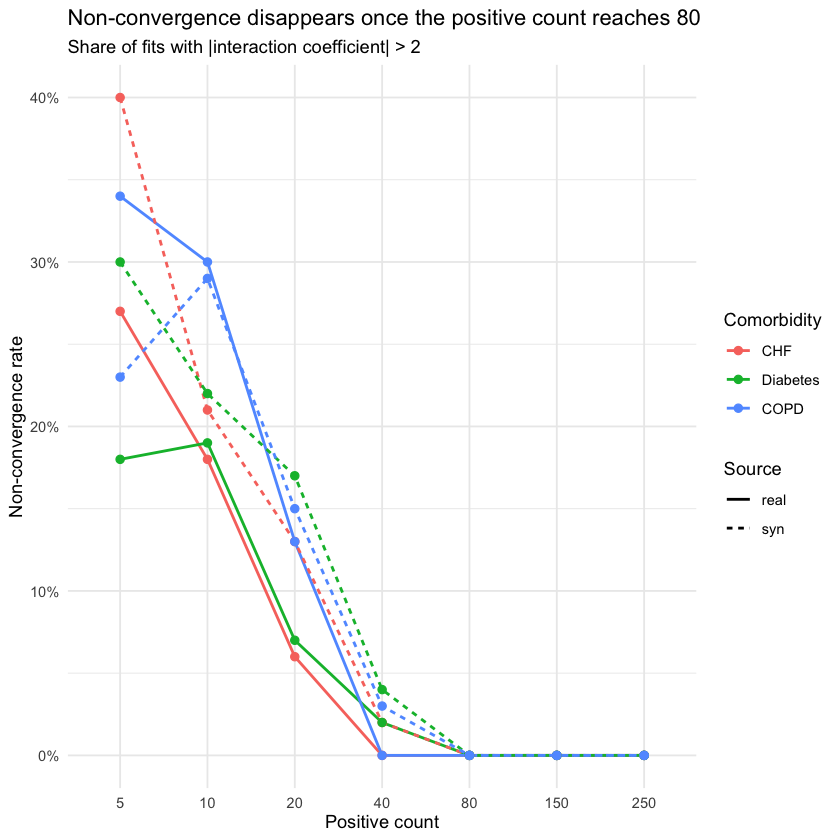

In [ ]:
explosion_long <- stability_compare %>%
  select(comorbidity, count, real = pct_real_expl, syn = pct_syn_expl) %>%
  pivot_longer(c(real, syn), names_to = "source", values_to = "pct_exploded") %>%
  mutate(comorbidity = factor(comorbidity, levels = c("CHF", "Diabetes", "COPD")))

p_nonconv <- ggplot(explosion_long, aes(x = factor(count), y = pct_exploded,
                           color = comorbidity, linetype = source,
                           group = interaction(comorbidity, source))) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  scale_y_continuous(labels = scales::percent, limits = c(0, NA)) +
  labs(title = "Non-convergence disappears once the positive count reaches 80",
       subtitle = paste0("Share of fits with |interaction coefficient| > ", EXPLODE_THRESHOLD),
       x = "Positive count", y = "Non-convergence rate",
       color = "Comorbidity", linetype = "Source") +
  theme_minimal()


In [32]:
all_results <- bind_rows(
  sweep_chf$results      %>% mutate(comorbidity = "CHF"),
  sweep_diabetes$results %>% mutate(comorbidity = "Diabetes"),
  sweep_copd$results     %>% mutate(comorbidity = "COPD")
)

all_results %>%
  group_by(comorbidity, count) %>%
  summarise(real_na = mean(is.na(real_est)),
            syn_na  = mean(is.na(syn_est)),
            .groups = "drop") %>%
  filter(real_na > 0 | syn_na > 0) %>%
  print(n = Inf)

threshold_rates <- lapply(c(2, 5, 10), function(thr) {
  all_results %>%
    group_by(comorbidity, count) %>%
    summarise(real = mean(abs(real_est) > thr, na.rm = TRUE),
              syn  = mean(abs(syn_est)  > thr, na.rm = TRUE),
              .groups = "drop") %>%
    mutate(threshold = thr)
}) %>% bind_rows()

threshold_rates %>%
  filter(real > 0 | syn > 0) %>%
  group_by(threshold) %>%
  summarise(cells       = n(),
            syn_higher  = sum(syn > real),
            real_higher = sum(real > syn),
            tied        = sum(syn == real),
            .groups = "drop") %>%
  print()

# A tibble: 3 × 4
  comorbidity count real_na syn_na
  <chr>       <dbl>   <dbl>  <dbl>
1 CHF             5       0   0.04
2 COPD            5       0   0.05
3 Diabetes        5       0   0.06
# A tibble: 3 × 5
  threshold cells syn_higher real_higher  tied
      <dbl> <int>      <int>       <int> <int>
1         2    12         10           2     0
2         5    11          8           2     1
3        10    10          8           2     0


In [33]:
threshold_rates %>%
  filter(count <= 40) %>%
  pivot_wider(names_from = threshold, values_from = c(real, syn),
              names_glue = "{.value}_t{threshold}") %>%
  arrange(comorbidity, count) %>%
  print(n = Inf)

# A tibble: 12 × 8
   comorbidity count real_t2 real_t5 real_t10 syn_t2 syn_t5 syn_t10
   <chr>       <dbl>   <dbl>   <dbl>    <dbl>  <dbl>  <dbl>   <dbl>
 1 CHF             5    0.27    0.21     0.18  0.417  0.323   0.271
 2 CHF            10    0.18    0.12     0.08  0.21   0.16    0.11 
 3 CHF            20    0.06    0.03     0.01  0.13   0.09    0.07 
 4 CHF            40    0       0        0     0.02   0.01    0    
 5 COPD            5    0.34    0.31     0.28  0.242  0.158   0.105
 6 COPD           10    0.3     0.18     0.11  0.29   0.17    0.12 
 7 COPD           20    0.13    0.05     0.04  0.15   0.09    0.07 
 8 COPD           40    0       0        0     0.03   0       0    
 9 Diabetes        5    0.18    0.13     0.11  0.319  0.255   0.223
10 Diabetes       10    0.19    0.14     0.1   0.22   0.15    0.12 
11 Diabetes       20    0.07    0.03     0.02  0.17   0.11    0.07 
12 Diabetes       40    0.02    0.01     0.01  0.04   0.01    0    


In [55]:
bind_rows(
  sweep_chf$quantile_summary      %>% mutate(comorbidity = "CHF"),
  sweep_diabetes$quantile_summary %>% mutate(comorbidity = "Diabetes"),
  sweep_copd$quantile_summary     %>% mutate(comorbidity = "COPD")
) %>%
  select(comorbidity, count, pct_real_na, pct_syn_na, pct_real_expl, pct_syn_expl) %>%
  print(n = Inf, width = Inf)

# A tibble: 21 × 6
   comorbidity count pct_real_na pct_syn_na pct_real_expl pct_syn_expl
   <chr>       <dbl>       <dbl>      <dbl>         <dbl>        <dbl>
 1 CHF             5           0       0.04          0.27         0.4 
 2 CHF            10           0       0             0.18         0.21
 3 CHF            20           0       0             0.06         0.13
 4 CHF            40           0       0             0            0.02
 5 CHF            80           0       0             0            0   
 6 CHF           150           0       0             0            0   
 7 CHF           250           0       0             0            0   
 8 Diabetes        5           0       0.06          0.18         0.3 
 9 Diabetes       10           0       0             0.19         0.22
10 Diabetes       20           0       0             0.07         0.17
11 Diabetes       40           0       0             0.02         0.04
12 Diabetes       80           0       0             0    

# Experiment 2: Size Sweep

Experiment 1 moves the positive count and the prevalence together, so neither can
be credited on its own. Fixing k and varying n moves prevalence alone.

`k_fixed = 20` comes from Experiment 1: the last count where fits still fail
often enough to matter (6-17% of replicates, against 0-4% at k = 40 and none from
k = 80 up), so sample size gets its best chance to show an effect. n runs 500 to
4000, matching the eight-fold rise of k going 20 to 150, and `M` is 100 in both
experiments.

Predictions, recorded before the run:

- **count drives fidelity** -> width flat across n, since k never changes
- **prevalence drives fidelity** -> width degrades as prevalence falls

What came out, across all three comorbidities:

- At k = 20 the synthetic table never loses the stratum, in any of the 15 cells.
  At k = 5 it does, 4-6% of the time. n = 2000 has the same 1% prevalence as the
  k = 5 cells, so the count is what separates them, not the share.
- Divergence does not track prevalence. Synthetic stays at 12-24% and real at
  2-14% across the whole grid, with synthetic the higher of the two in 14 of the
  15 cells. The one tie is COPD at n = 4000, both at 12%.
- COPD is the only comorbidity with a positive interaction (+0.0668), and at
  k = 20 the synthetic median is negative at all five sample sizes, -0.077 to
  -0.159. Experiment 1 recorded -0.177 at the same count and recovers the sign
  by k = 40. Raising k fixes it; raising n does not.
- The width prediction cannot be settled here. Monte Carlo error at `M = 100` is
  about the same size as the variation across n.

In [43]:
k_fixed <- 20
sizes   <- c(250, 500, 1000, 2000, 4000)
M_SIZE  <- 100

size_chf      <- run_size_sweep("chf",      pool, k_fixed, sizes, M_SIZE)
size_diabetes <- run_size_sweep("diabetes", pool, k_fixed, sizes, M_SIZE)
size_copd     <- run_size_sweep("copd",     pool, k_fixed, sizes, M_SIZE)

size_compare <- bind_rows(
  size_chf$quantile_summary      %>% mutate(comorbidity = "CHF"),
  size_diabetes$quantile_summary %>% mutate(comorbidity = "Diabetes"),
  size_copd$quantile_summary     %>% mutate(comorbidity = "COPD")
) %>%
  select(comorbidity, n_fixed, prevalence, pct_real_na, pct_syn_na,
         pct_real_expl, pct_syn_expl, real_width, syn_width)

print(size_compare, width = Inf, n = Inf)

# A tibble: 15 × 9
   comorbidity n_fixed prevalence pct_real_na pct_syn_na pct_real_expl
   <chr>         <dbl>      <dbl>       <dbl>      <dbl>         <dbl>
 1 CHF             250      0.08            0          0          0.02
 2 CHF             500      0.04            0          0          0.08
 3 CHF            1000      0.02            0          0          0.08
 4 CHF            2000      0.01            0          0          0.07
 5 CHF            4000      0.005           0          0          0.1 
 6 Diabetes        250      0.08            0          0          0.08
 7 Diabetes        500      0.04            0          0          0.12
 8 Diabetes       1000      0.02            0          0          0.06
 9 Diabetes       2000      0.01            0          0          0.1 
10 Diabetes       4000      0.005           0          0          0.11
11 COPD            250      0.08            0          0          0.14
12 COPD            500      0.04            0          0  

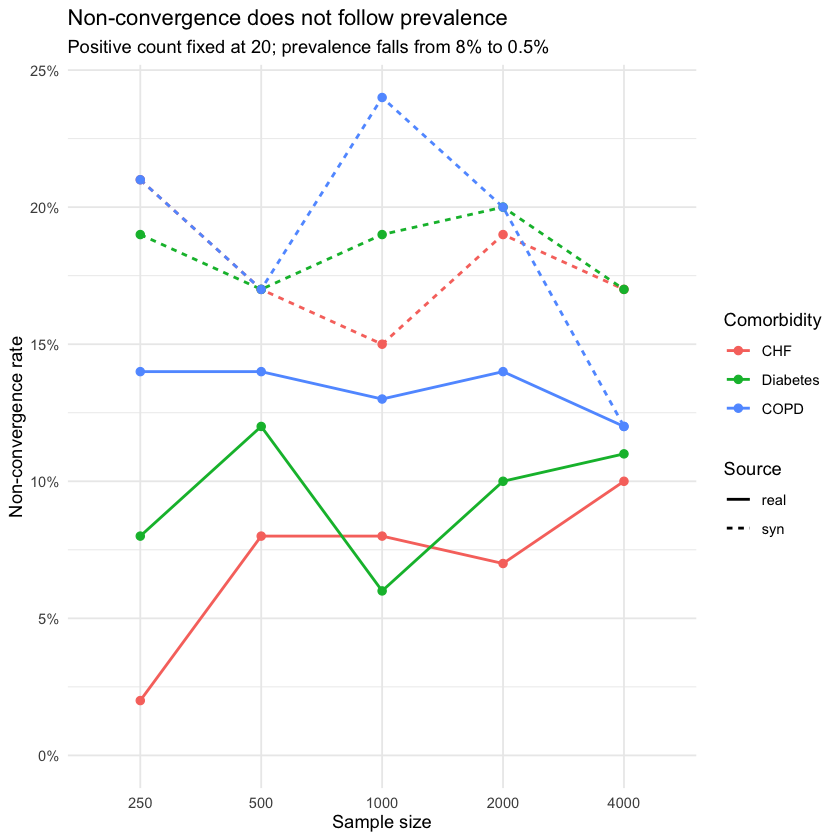

In [44]:
size_expl_long <- size_compare %>%
  select(comorbidity, n_fixed, real = pct_real_expl, syn = pct_syn_expl) %>%
  pivot_longer(c(real, syn), names_to = "source", values_to = "pct_exploded") %>%
  mutate(comorbidity = factor(comorbidity, levels = c("CHF", "Diabetes", "COPD")))

p_size_diverge <- ggplot(size_expl_long, aes(x = factor(n_fixed), y = pct_exploded,
                           color = comorbidity, linetype = source,
                           group = interaction(comorbidity, source))) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  scale_y_continuous(labels = scales::percent, limits = c(0, NA)) +
  labs(title = "Non-convergence does not follow prevalence",
       subtitle = "Positive count fixed at 20; prevalence falls from 8% to 0.5%",
       x = "Sample size", y = "Non-convergence rate",
       color = "Comorbidity", linetype = "Source") +
  theme_minimal()

p_size_diverge

In [45]:
print(size_compare, width = Inf, n = Inf)

# A tibble: 15 × 9
   comorbidity n_fixed prevalence pct_real_na pct_syn_na pct_real_expl
   <chr>         <dbl>      <dbl>       <dbl>      <dbl>         <dbl>
 1 CHF             250      0.08            0          0          0.02
 2 CHF             500      0.04            0          0          0.08
 3 CHF            1000      0.02            0          0          0.08
 4 CHF            2000      0.01            0          0          0.07
 5 CHF            4000      0.005           0          0          0.1 
 6 Diabetes        250      0.08            0          0          0.08
 7 Diabetes        500      0.04            0          0          0.12
 8 Diabetes       1000      0.02            0          0          0.06
 9 Diabetes       2000      0.01            0          0          0.1 
10 Diabetes       4000      0.005           0          0          0.11
11 COPD            250      0.08            0          0          0.14
12 COPD            500      0.04            0          0  

# Lever Comparison

Both experiments on one pair of axes. k runs 20 to 150 at fixed n, n runs 500 to
4000 at fixed k, each about an eight-fold increase.

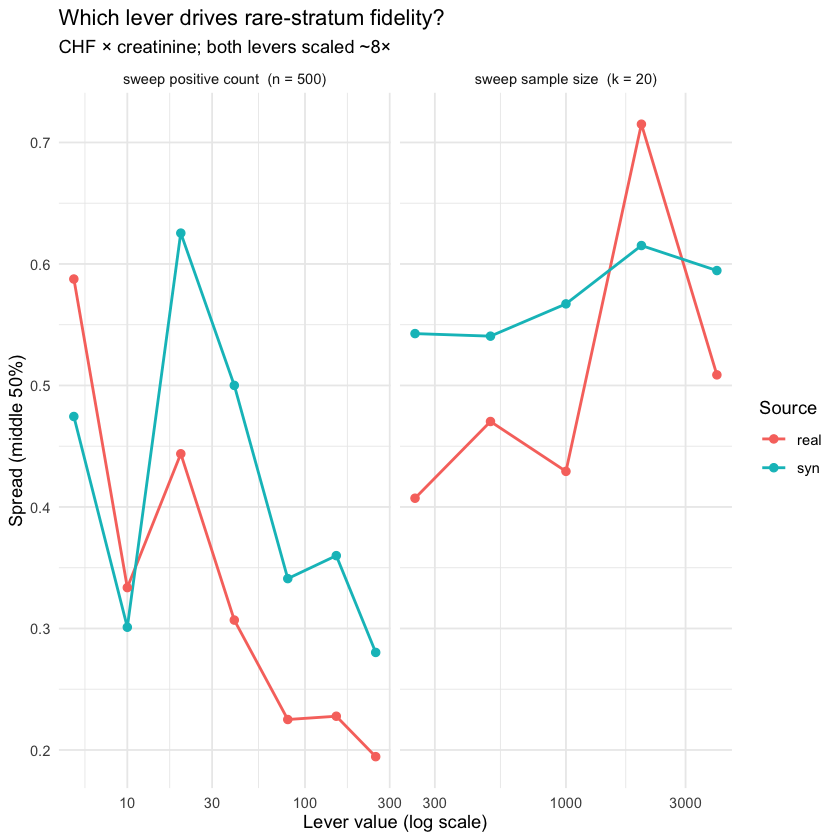

In [52]:
lever_compare <- bind_rows(
  sweep_chf$quantile_summary %>%
    transmute(lever = "sweep positive count  (n = 500)", x = count,
              real = real_width, syn = syn_width),
  size_chf$quantile_summary %>%
    transmute(lever = "sweep sample size  (k = 20)", x = n_fixed,
              real = real_width, syn = syn_width)
) %>%
  pivot_longer(c(real, syn), names_to = "source", values_to = "iqr_width")

ggplot(lever_compare, aes(x = x, y = iqr_width, color = source)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  facet_wrap(~ lever, scales = "free_x") +
  scale_x_log10() +
  labs(title = "Which lever drives rare-stratum fidelity?",
       subtitle = "CHF × creatinine; both levers scaled ~8×",
       x = "Lever value (log scale)", y = "Spread (middle 50%)",
       color = "Source") +
  theme_minimal()

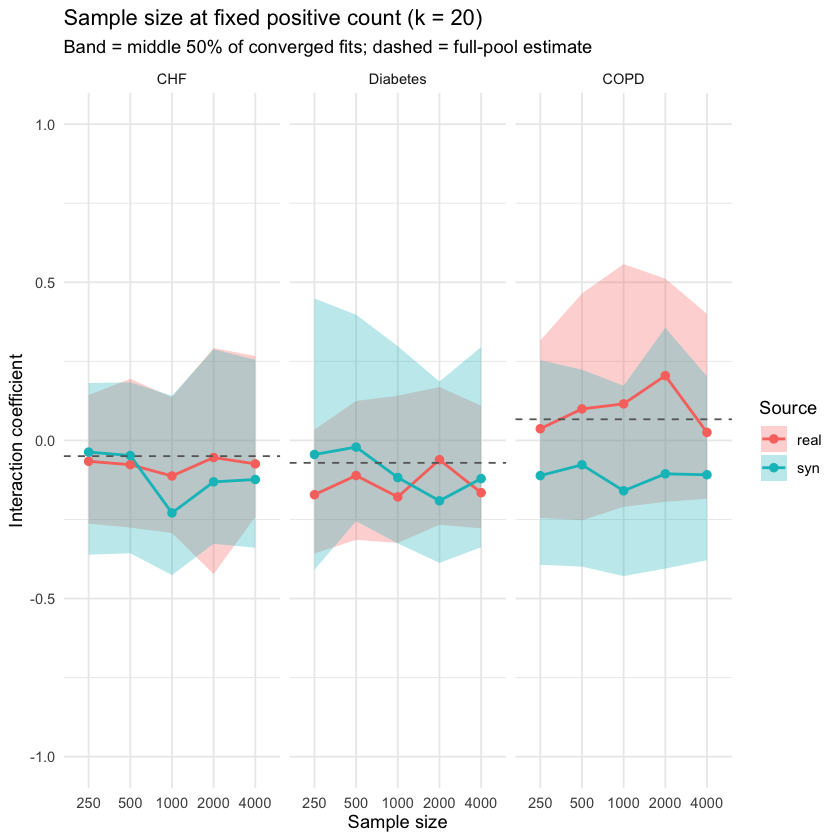

In [53]:
size_plot_df <- bind_rows(
    size_chf$quantile_summary      %>% mutate(comorbidity = "CHF"),
    size_diabetes$quantile_summary %>% mutate(comorbidity = "Diabetes"),
    size_copd$quantile_summary     %>% mutate(comorbidity = "COPD")
  ) %>%
  pivot_longer(
    cols = matches("^(real|syn)_q[0-9]+$"),   # skip pct_*/width/prevalence columns
    names_to = c("source", "quantile"),
    names_pattern = "(real|syn)_q(\\d+)",
    values_to = "value"
  ) %>%
  mutate(quantile = paste0("q", quantile)) %>%
  pivot_wider(names_from = quantile, values_from = value) %>%
  mutate(comorbidity = factor(comorbidity, levels = c("CHF", "Diabetes", "COPD")))

p_size_ribbon <- ggplot(size_plot_df, aes(x = factor(n_fixed), color = source, fill = source)) +
  geom_ribbon(aes(ymin = q25, ymax = q75, group = source), alpha = 0.3, color = NA) +
  geom_line(aes(y = q50, group = source), linewidth = 0.8) +
  geom_point(aes(y = q50), size = 2) +
  geom_hline(data = ref_df, aes(yintercept = full_est),
             linetype = "dashed", color = "grey40") +
  facet_wrap(~ comorbidity) +
  coord_cartesian(ylim = c(-1, 1)) +
  labs(title = "Sample size at fixed positive count (k = 20)",
       subtitle = "Band = middle 50% of converged fits; dashed = full-pool estimate",
       x = "Sample size", y = "Interaction coefficient",
       color = "Source", fill = "Source") +
  theme_minimal()
p_size_ribbon

In [54]:
size_plot_df %>%
  select(comorbidity, n_fixed, prevalence, source, q25, q50, q75) %>%
  arrange(comorbidity, n_fixed, source) %>%
  print(n = Inf, width = Inf)

# A tibble: 30 × 7
   comorbidity n_fixed prevalence source    q25     q50    q75
   <fct>         <dbl>      <dbl> <chr>   <dbl>   <dbl>  <dbl>
 1 CHF             250      0.08  real   -0.263 -0.0660 0.144 
 2 CHF             250      0.08  syn    -0.361 -0.0369 0.182 
 3 CHF             500      0.04  real   -0.276 -0.0767 0.195 
 4 CHF             500      0.04  syn    -0.357 -0.0479 0.184 
 5 CHF            1000      0.02  real   -0.293 -0.112  0.136 
 6 CHF            1000      0.02  syn    -0.426 -0.229  0.141 
 7 CHF            2000      0.01  real   -0.423 -0.0541 0.292 
 8 CHF            2000      0.01  syn    -0.327 -0.131  0.288 
 9 CHF            4000      0.005 real   -0.242 -0.0742 0.267 
10 CHF            4000      0.005 syn    -0.339 -0.124  0.255 
11 Diabetes        250      0.08  real   -0.358 -0.172  0.0341
12 Diabetes        250      0.08  syn    -0.409 -0.0445 0.449 
13 Diabetes        500      0.04  real   -0.315 -0.111  0.125 
14 Diabetes        500      0.04  sy